# Study 15 — Visual Tour: Clusters, Entity Graph, Stories

A visual walkthrough of the pipeline fixed in this session:
1. **Clusters** — RSS docs in embedding space, colored by micro-event (complete-linkage)
2. **Entity graph** — co-occurrence network (top connected entities, canonicalized)
3. **Stories** — micro-events fused into macro-stories (Khamenei case: 22 fragments → 12 groups)

In [1]:
import os, sqlite3, sqlite_vec, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from sklearn.decomposition import PCA

notebook_dir = Path.cwd()
while not (notebook_dir / 'data/db/pathosphere.db').exists():
    notebook_dir = notebook_dir.parent
    if notebook_dir == notebook_dir.parent: break
os.chdir(notebook_dir)

DB = Path('data/db/pathosphere.db').resolve()
CONN = sqlite3.connect(str(DB))
CONN.enable_load_extension(True)
sqlite_vec.load(CONN)
CONN.enable_load_extension(False)
CONN.row_factory = sqlite3.Row
print(f'Connected: {DB}')

Connected: /Users/dom/Documents/GitHub/pathosphere/data/db/pathosphere.db


## 1. Clusters — Embedding Space

In [2]:
rss_events = CONN.execute('''
    SELECT e.id, e.title, COUNT(ed.document_id) as size
    FROM events e LEFT JOIN event_documents ed ON e.id = ed.event_id
    WHERE e.origin IN ("rss","comtrade") GROUP BY e.id ORDER BY size DESC
''').fetchall()

all_docs = CONN.execute('''
    SELECT DISTINCT ed.document_id, ed.event_id
    FROM event_documents ed JOIN raw_documents r ON ed.document_id = r.id
    WHERE r.origin IN ("rss","comtrade")
''').fetchall()
doc_to_event = {d['document_id']: d['event_id'] for d in all_docs}

embeddings, valid_doc_ids = [], []
for doc_id in doc_to_event.keys():
    vec_row = CONN.execute('SELECT embedding FROM vec_documents WHERE document_id = ?', (doc_id,)).fetchone()
    if vec_row and vec_row['embedding']:
        embeddings.append(np.frombuffer(vec_row['embedding'], dtype=np.float32).copy())
        valid_doc_ids.append(doc_id)
embeddings = np.array(embeddings)
print(f'{len(rss_events)} events, {len(embeddings)} embedded docs')

1996 events, 2564 embedded docs


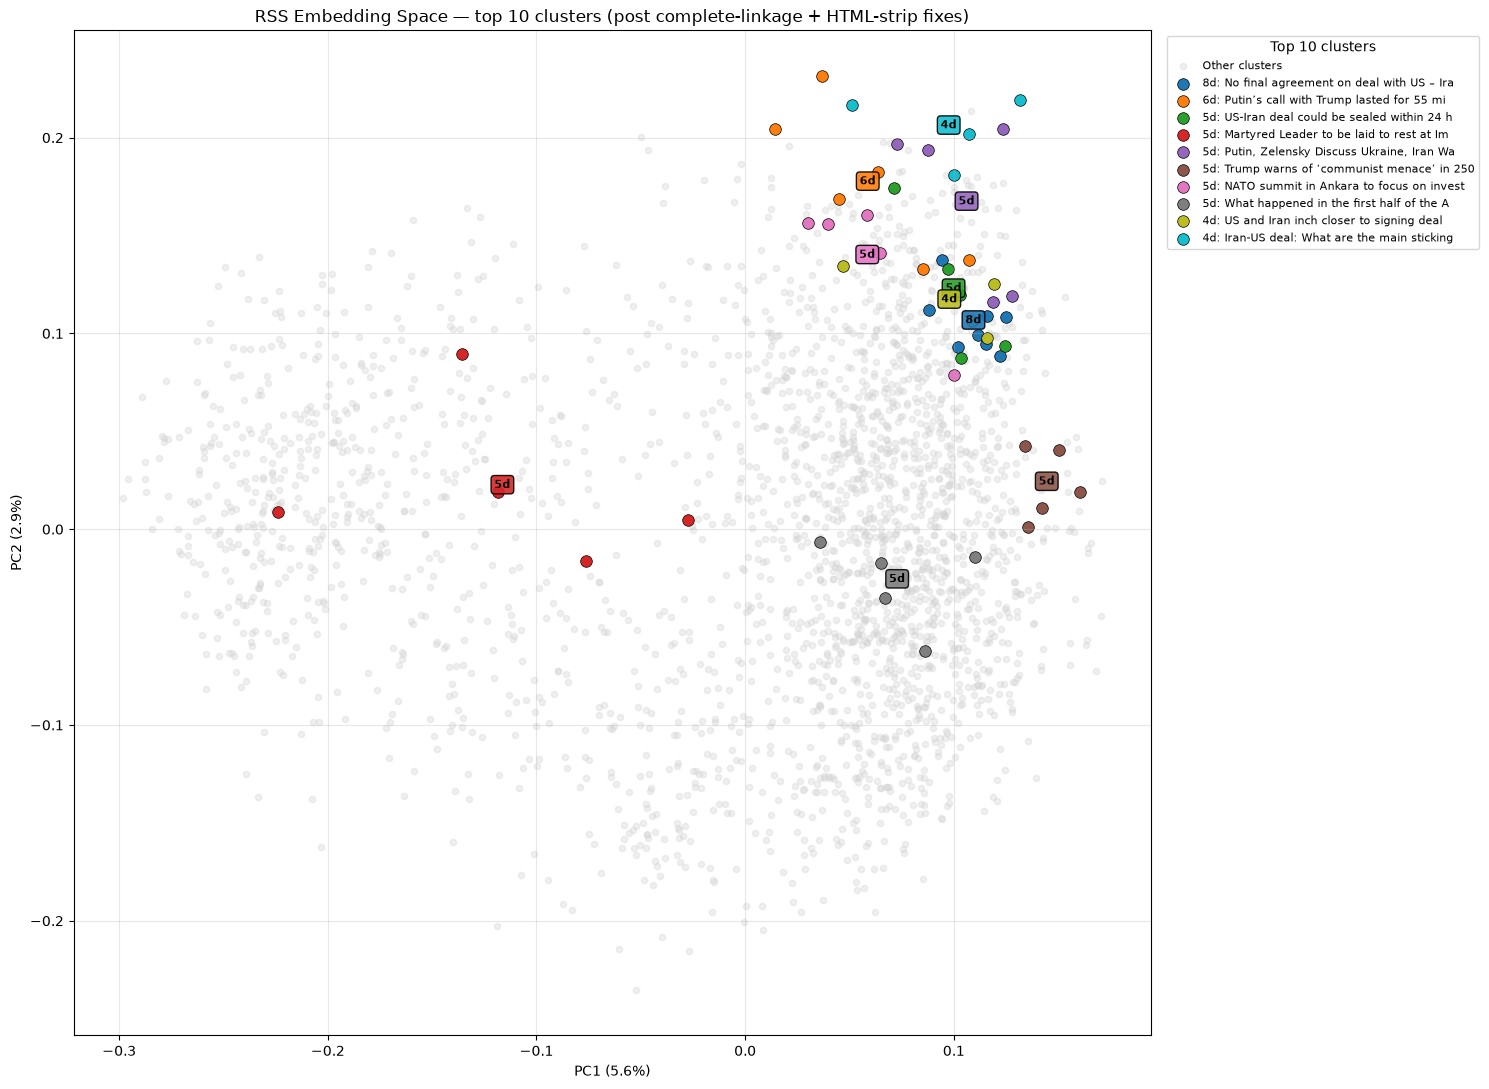

In [3]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
cluster_labels = np.array([doc_to_event[d] for d in valid_doc_ids])
top10_ids = [e['id'] for e in rss_events[:10]]
palette = plt.cm.tab10(np.linspace(0, 1, 10))
id_to_color = {cid: palette[i] for i, cid in enumerate(top10_ids)}

fig, ax = plt.subplots(figsize=(15, 11))
is_top10 = np.array([cid in id_to_color for cid in cluster_labels])
ax.scatter(emb_2d[~is_top10, 0], emb_2d[~is_top10, 1], c='lightgray', s=20, alpha=0.35, label='Other clusters')
for cid in top10_ids:
    mask = cluster_labels == cid
    event = next(e for e in rss_events if e['id'] == cid)
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], color=id_to_color[cid], s=70,
               edgecolor='black', linewidth=0.5, label=f"{event['size']}d: {event['title'][:40]}")
    centroid = emb_2d[mask].mean(axis=0)
    ax.annotate(f"{event['size']}d", xy=centroid, fontsize=8, ha='center', weight='bold',
               bbox=dict(boxstyle='round', facecolor=id_to_color[cid], alpha=0.9, edgecolor='black'))
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('RSS Embedding Space — top 10 clusters (post complete-linkage + HTML-strip fixes)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, title='Top 10 clusters')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('study_15_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Entity Graph — Co-occurrence Network

In [4]:
# Top N entities by degree (mention count), canonical-resolved
TOP_N = 50

links = CONN.execute('''
    SELECT
        COALESCE(ea.canonical_entity_id, ea.id) as a,
        COALESCE(eb.canonical_entity_id, eb.id) as b,
        el.strength
    FROM entity_links el
    JOIN entities ea ON el.entity_a = ea.id
    JOIN entities eb ON el.entity_b = eb.id
    WHERE el.relation_type = "co-occurs"
''').fetchall()

G_full = nx.Graph()
for l in links:
    if l['a'] == l['b']:
        continue
    if G_full.has_edge(l['a'], l['b']):
        G_full[l['a']][l['b']]['weight'] += l['strength']
    else:
        G_full.add_edge(l['a'], l['b'], weight=l['strength'])

print(f'Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges')

# Subgraph: top N nodes by degree
top_nodes = sorted(G_full.degree, key=lambda x: -x[1])[:TOP_N]
top_node_ids = [n for n, _ in top_nodes]
G = G_full.subgraph(top_node_ids).copy()
print(f'Subgraph (top {TOP_N} by degree): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Full graph: 8821 nodes, 80884 edges
Subgraph (top 50 by degree): 50 nodes, 776 edges


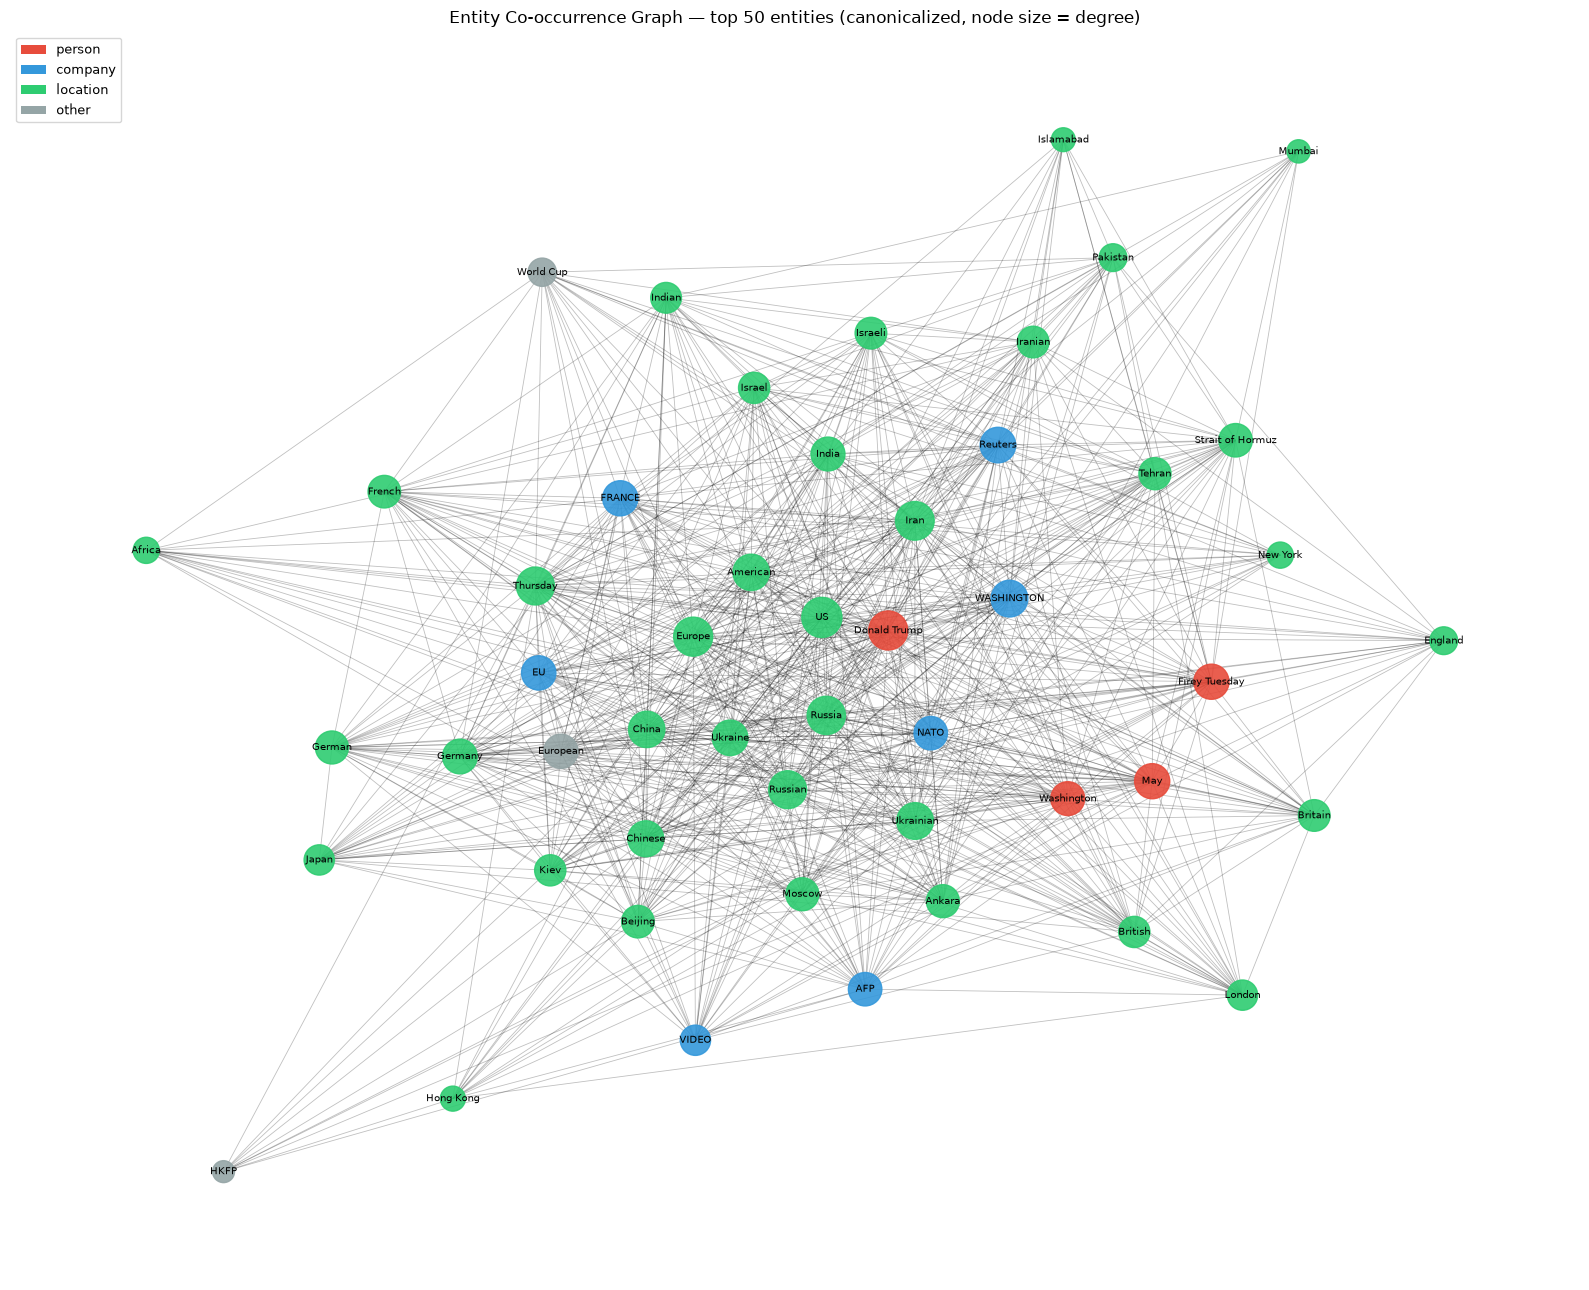

In [5]:
# Node labels + colors by entity_type
node_info = {}
for nid in G.nodes():
    row = CONN.execute('SELECT name, entity_type FROM entities WHERE id = ?', (nid,)).fetchone()
    node_info[nid] = (row['name'], row['entity_type']) if row else (str(nid), 'other')

type_colors = {
    'person': '#e74c3c', 'company': '#3498db', 'location': '#2ecc71',
    'commodity': '#f39c12', 'infrastructure': '#9b59b6', 'other': '#95a5a6',
}
node_colors = [type_colors.get(node_info[n][1], '#95a5a6') for n in G.nodes()]
node_sizes = [100 + 15 * G.degree(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 13))
pos = nx.spring_layout(G, k=0.6, seed=42, weight='weight')
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
labels = {n: node_info[n][0][:20] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=t) for t, c in type_colors.items() if any(node_info[n][1]==t for n in G.nodes())]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(f'Entity Co-occurrence Graph — top {TOP_N} entities (canonicalized, node size = degree)')
ax.axis('off')
plt.tight_layout()
plt.savefig('study_15_entity_graph.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Stories — Micro-events Fused via Entity + Time + Embedding

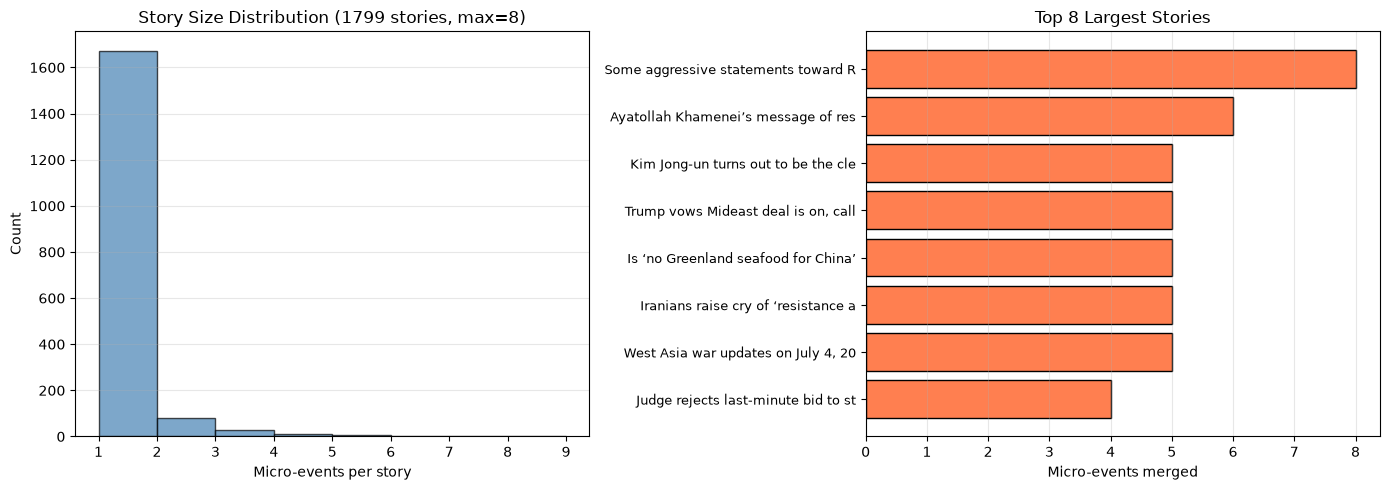

In [6]:
# Story size distribution
story_sizes = CONN.execute('''
    SELECT COALESCE(story_id, id) as sid, COUNT(*) as c
    FROM events WHERE origin IN ("rss","comtrade")
    GROUP BY sid
''').fetchall()
sizes = [r['c'] for r in story_sizes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(sizes, bins=range(1, max(sizes)+2), edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Micro-events per story')
ax1.set_ylabel('Count')
ax1.set_title(f'Story Size Distribution ({len(sizes)} stories, max={max(sizes)})')
ax1.grid(alpha=0.3, axis='y')

top_stories = sorted(story_sizes, key=lambda r: -r['c'])[:8]
titles = [CONN.execute('SELECT title FROM events WHERE id=?', (r['sid'],)).fetchone()['title'][:35] for r in top_stories]
counts = [r['c'] for r in top_stories]
ax2.barh(range(len(titles)), counts, color='coral', edgecolor='black')
ax2.set_yticks(range(len(titles)))
ax2.set_yticklabels(titles, fontsize=9)
ax2.set_xlabel('Micro-events merged')
ax2.set_title('Top 8 Largest Stories')
ax2.invert_yaxis()
ax2.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('study_15_story_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

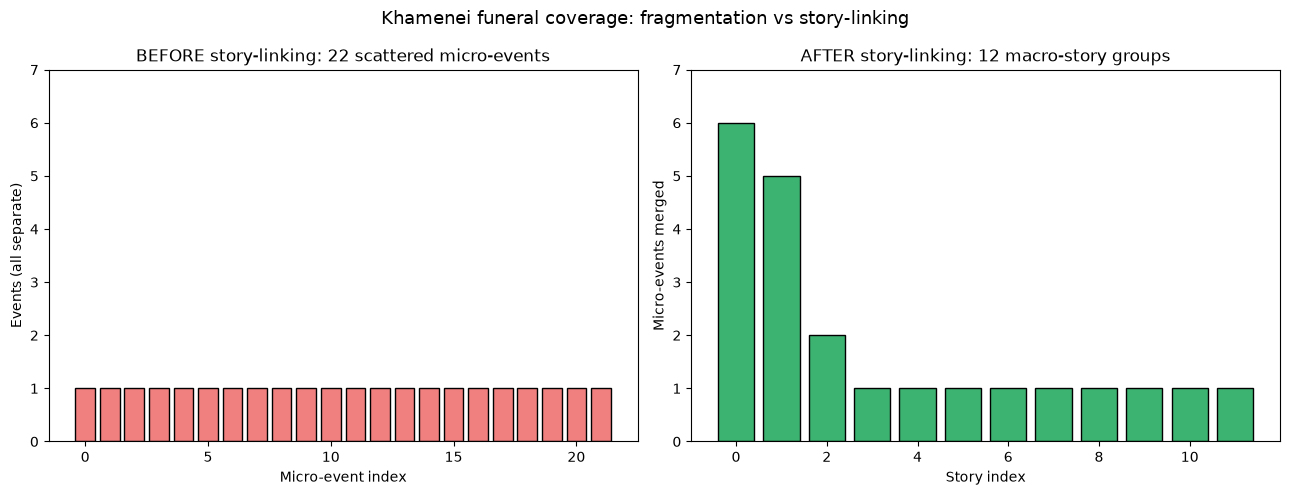

22 micro-events -> 12 macro-stories (largest: 6)


In [7]:
# Khamenei case: before (scattered micro-events) vs after (macro-story groups)
canon = CONN.execute("SELECT id FROM entities WHERE name='Ayatollah Ali Khamenei' AND entity_type='person'").fetchone()
if canon:
    canon_id = canon['id']
    micro_events = set(r['event_id'] for r in CONN.execute('''
        SELECT DISTINCT ed.event_id FROM document_entities de
        JOIN entities e ON de.entity_id = e.id
        JOIN event_documents ed ON de.document_id = ed.document_id
        WHERE COALESCE(e.canonical_entity_id, e.id) = ?
    ''', (canon_id,)).fetchall())

    from collections import Counter
    story_counts = Counter()
    for eid in micro_events:
        row = CONN.execute('SELECT story_id FROM events WHERE id=?', (eid,)).fetchone()
        story_counts[row['story_id'] or eid] += 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Before: every micro-event as its own bar (all height 1)
    ax1.bar(range(len(micro_events)), [1]*len(micro_events), color='lightcoral', edgecolor='black')
    ax1.set_title(f'BEFORE story-linking: {len(micro_events)} scattered micro-events')
    ax1.set_xlabel('Micro-event index')
    ax1.set_ylabel('Events (all separate)')
    ax1.set_ylim(0, max(story_counts.values())+1)

    # After: grouped into macro-stories
    vals = sorted(story_counts.values(), reverse=True)
    ax2.bar(range(len(vals)), vals, color='mediumseagreen', edgecolor='black')
    ax2.set_title(f'AFTER story-linking: {len(vals)} macro-story groups')
    ax2.set_xlabel('Story index')
    ax2.set_ylabel('Micro-events merged')
    ax2.set_ylim(0, max(story_counts.values())+1)

    plt.suptitle('Khamenei funeral coverage: fragmentation vs story-linking', fontsize=13)
    plt.tight_layout()
    plt.savefig('study_15_khamenei_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{len(micro_events)} micro-events -> {len(vals)} macro-stories (largest: {vals[0]})')
else:
    print('Canonical Khamenei entity not found (re-run pathos extract if DB changed)')

## Summary

In [8]:
print(f'''
VISUAL TOUR SUMMARY
====================
Clusters: {len(rss_events)} events, {len(embeddings)} embedded docs (complete-linkage, HTML-clean)
Entity graph: {G_full.number_of_nodes()} entities, {G_full.number_of_edges()} co-occurrence links
  (top {TOP_N} shown by degree)
Stories: {len(sizes)} groups, max {max(sizes)} micro-events fused (was 206 before the
  group-vs-group complete-linkage fix)

Saved:
  study_15_clusters.png
  study_15_entity_graph.png
  study_15_story_sizes.png
  study_15_khamenei_before_after.png
''')


VISUAL TOUR SUMMARY
Clusters: 1996 events, 2564 embedded docs (complete-linkage, HTML-clean)
Entity graph: 8821 entities, 80884 co-occurrence links
  (top 50 shown by degree)
Stories: 1799 groups, max 8 micro-events fused (was 206 before the
  group-vs-group complete-linkage fix)

Saved:
  study_15_clusters.png
  study_15_entity_graph.png
  study_15_story_sizes.png
  study_15_khamenei_before_after.png

